In [2]:
# 0. ОПРЕДЕЛЕНИЕ МОДЕЛИ UNet
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        for feature in features:
            self.encoder.append(DoubleConv(in_channels, feature))
            in_channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for feature in reversed(features):
            self.decoder.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.decoder.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for encoder in self.encoder:
            x = encoder(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.decoder), 2):
            x = self.decoder[idx](x)
            skip = skip_connections[idx // 2]

            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)

            x = torch.cat((skip, x), dim=1)
            x = self.decoder[idx + 1](x)

        return torch.sigmoid(self.final_conv(x))

print("UNet определена")


# 1. ВЫБОР РЕЖИМА РАБОТЫ
print("\nВыберите режим работы:")
print("1. Новое обучение (с нуля)")
print("2. Дообучение (загрузка сохраненной модели)")

mode = input("\nВведите номер режима (1 или 2): ").strip()

if mode == "1":
    print("\nВыбран режим: НОВОЕ ОБУЧЕНИЕ")
    mode_type = "new"
    USE_PRETRAINED = False
    model = None
    PRETRAINED_MODEL_PATH = None
elif mode == "2":
    print("\nВыбран режим: ДООБУЧЕНИЕ")
    mode_type = "finetune"
    USE_PRETRAINED = True
else:
    print("\nНекорректный ввод. По умолчанию выбран режим: НОВОЕ ОБУЧЕНИЕ")
    mode_type = "new"
    USE_PRETRAINED = False
    model = None
    PRETRAINED_MODEL_PATH = None

print("="*60)


UNet определена

Выберите режим работы:
1. Новое обучение (с нуля)
2. Дообучение (загрузка сохраненной модели)

Введите номер режима (1 или 2): 2

Выбран режим: ДООБУЧЕНИЕ


In [3]:
# 2. Установка библиотек
!pip install rasterio matplotlib numpy torch tqdm requests -q

import os
import zipfile
import requests
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.plot import show
import torch
from torch.utils.data import Dataset, DataLoader
import glob
import json
from torch.optim import Adam
from torch.utils.data import random_split
import time

In [4]:
# 3. ЗАГРУЗКА МОДЕЛИ ДЛЯ ДООБУЧЕНИЯ
if USE_PRETRAINED:
    from google.colab import files
    import glob

    print("\n" + "="*50)
    print("ЗАГРУЗКА МОДЕЛИ ДЛЯ ДООБУЧЕНИЯ")

    # Проверяем, есть ли уже модель в /content/
    content_models = glob.glob("/content/*.pth")

    if content_models:
        print("\nНайдены модели в директории /content/:")
        for i, model_file in enumerate(content_models):
            model_name = os.path.basename(model_file)
            size_mb = os.path.getsize(model_file) / (1024 * 1024)
            print(f"  {i+1}. {model_name} ({size_mb:.1f} МБ)")

        print("\nВыберите действие:")
        print("1. Использовать существующую модель из /content/")
        print("2. Загрузить новую модель с компьютера")

        choice = input("\nВведите номер действия (1 или 2): ").strip()

        if choice == "1":
            # Используем существующую модель
            model_idx = int(input(f"Введите номер модели (1-{len(content_models)}): ").strip()) - 1
            if 0 <= model_idx < len(content_models):
                model_path = content_models[model_idx]
                print(f"\nИспользуем модель: {os.path.basename(model_path)}")
            else:
                print("Неверный номер. Переключение на загрузку с компьютера...")
                choice = "2"

    # Если выбрана загрузка с компьютера или нет моделей в /content/
    if not content_models or choice == "2":
        print("\nЗагрузите файл модели (.pth)")
        print("Нажмите 'Choose Files' и выберите файл модели")

        uploaded = files.upload()

        if uploaded:
            # Сохраняем загруженную модель в /content/
            model_path = list(uploaded.keys())[0]
            # Перемещаем в /content/ если она не там
            if not model_path.startswith('/content/'):
                new_path = os.path.join('/content', model_path)
                # Если файл уже существует в /content/, переименовываем
                if os.path.exists(new_path):
                    base, ext = os.path.splitext(model_path)
                    new_path = os.path.join('/content', f"{base}_new{ext}")
                os.rename(model_path, new_path)
                model_path = new_path

            print(f"\nМодель сохранена: {model_path}")
        else:
            print("Модель не загружена. Переключение на режим нового обучения...")
            USE_PRETRAINED = False
            model = None
            PRETRAINED_MODEL_PATH = None

    # Загружаем модель (если она определена)
    if USE_PRETRAINED and 'model_path' in locals() and model_path:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

        try:
            checkpoint = torch.load(model_path, map_location=device)

            # UNet определён!
            model = UNet(in_channels=3, out_channels=1)
            model.load_state_dict(checkpoint['model_state_dict'])
            model = model.to(device)
            model.eval()

            train_losses = checkpoint.get('train_losses', [])
            val_losses = checkpoint.get('val_losses', [])
            start_epoch = checkpoint.get('epoch', 0)

            print(f"\nМодель успешно загружена!")
            print(f"  - Эпоха: {start_epoch}")
            print(f"  - Train Loss: {train_losses[-1] if train_losses else '?'}")
            print(f"  - Val Loss: {val_losses[-1] if val_losses else '?'}")

            PRETRAINED_MODEL_PATH = model_path

        except Exception as e:
            print(f"Ошибка при загрузке модели: {e}")
            print("Переключение на режим нового обучения...")
            USE_PRETRAINED = False
            model = None
            PRETRAINED_MODEL_PATH = None

# 4. Настройка параметров
# Параметры загрузки
if mode_type == "new":
    # При новом обучении загружаем одну часть
    PARTS_TO_DOWNLOAD = [1]  # Меняем. Сейчас загружена 1 и 5 часть
    print(f"Режим нового обучения: загрузка части {PARTS_TO_DOWNLOAD}")
else:
    # При дообучении загружаем следующую часть
    # Загружаем следующую часть после той, что уже использовалась
    # Если использовалась часть 1, загружаем часть 2
    print("Режим дообучения: загрузка новой части данных")

    # Предлагаем выбрать часть
    print("\nДоступные части: 1-8")
    part_num = input("Введите номер части для дообучения (например, 2): ").strip()
    try:
        part_num = int(part_num)
        if 1 <= part_num <= 8:
            PARTS_TO_DOWNLOAD = [part_num]
        else:
            print("Неверный номер, загружаем часть 2 по умолчанию")
            PARTS_TO_DOWNLOAD = [2]
    except:
        print("Неверный ввод, загружаем часть 2")
        PARTS_TO_DOWNLOAD = [2]

# URL для скачивания с Zenodo
BASE_URL = "https://zenodo.org/records/11278238/files"

# Директории
DATA_DIR = "/content/s1s2_water_data"
ZIP_DIR = os.path.join(DATA_DIR, "zips")
EXTRACT_DIR = os.path.join(DATA_DIR, "extracted")

# Создаем директории
os.makedirs(ZIP_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

print(f"Рабочая директория: {DATA_DIR}")
print(f"Будет загружено {len(PARTS_TO_DOWNLOAD)} частей (из 8)")


ЗАГРУЗКА МОДЕЛИ ДЛЯ ДООБУЧЕНИЯ

Найдены модели в директории /content/:
  1. unet_water_s1s2_20260622_021848.pth (118.5 МБ)

Выберите действие:
1. Использовать существующую модель из /content/
2. Загрузить новую модель с компьютера

Введите номер действия (1 или 2): 2

Загрузите файл модели (.pth)
Нажмите 'Choose Files' и выберите файл модели


Saving unet_water_s1s2_20260622_021848.pth to unet_water_s1s2_20260622_021848 (1).pth

Модель сохранена: /content/unet_water_s1s2_20260622_021848 (1)_new.pth

Модель успешно загружена!
  - Эпоха: 30
  - Train Loss: 0.47842157632112503
  - Val Loss: 0.37191587686538696
Режим дообучения: загрузка новой части данных

Доступные части: 1-8
Введите номер части для дообучения (например, 2): 3
Рабочая директория: /content/s1s2_water_data
Будет загружено 1 частей (из 8)


In [5]:
# 5. Функция для скачивания с прогресс-баром
def download_file(url, dest_path):
    """Скачивает файл с отображением прогресса"""
    try:
        response = requests.get(url, stream=True, timeout=60)
        response.raise_for_status()
        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024 * 1024  # 1 МБ

        with open(dest_path, 'wb') as file:
            with tqdm(total=total_size, unit='B', unit_scale=True, desc=os.path.basename(dest_path)) as pbar:
                for data in response.iter_content(block_size):
                    file.write(data)
                    pbar.update(len(data))
        print(f"Скачано: {dest_path}")
        return True
    except Exception as e:
        print(f"Ошибка при скачивании: {e}")
        if os.path.exists(dest_path):
            os.remove(dest_path)
        return False

# 6. Загрузка и распаковка частей
print("ЗАГРУЗКА ДАННЫХ")
print("="*50)

# Проверяем, какие части уже загружены
available_parts = []
for part_num in range(1, 9):  # Проверяем части 1-8
    extract_part_dir = os.path.join(EXTRACT_DIR, f"part{part_num}")
    if os.path.exists(extract_part_dir) and len(os.listdir(extract_part_dir)) > 0:
        available_parts.append(part_num)

if available_parts:
    print(f"\nНайдены уже загруженные части: {available_parts}")
    print(f"   (Всего: {len(available_parts)} частей)")

    # Проверяем, есть ли нужная часть среди уже загруженных
    needed_parts = set(PARTS_TO_DOWNLOAD)
    available_needed = needed_parts.intersection(set(available_parts))
    missing_parts = needed_parts - set(available_parts)

    if available_needed:
        print(f"Нужные части уже загружены: {sorted(available_needed)}")

    if missing_parts:
        print(f"Будет загружено: {sorted(missing_parts)}")
        PARTS_TO_DOWNLOAD = sorted(missing_parts)
    else:
        print("Все нужные части уже загружены! Пропускаем скачивание.")
        successful_parts = sorted(available_needed)
        # Если все части уже есть, пропускаем скачивание
        if successful_parts:
            print(f"\nУспешно загружено: {len(successful_parts)} частей")
            # Пропускаем блок скачивания
            # Используем already_loaded = True для пропуска
            already_loaded = True
else:
    print("\nНет загруженных частей. Начинаем скачивание...")
    already_loaded = False

# Скачиваем только если есть недостающие части
if not already_loaded and PARTS_TO_DOWNLOAD:
    print("НАЧАЛО СКАЧИВАНИЯ")
    print("="*50)

    successful_parts = []

    for part_num in PARTS_TO_DOWNLOAD:
        # Формируем URL для скачивания
        zip_filename = f"part{part_num}.zip"
        zip_url = f"{BASE_URL}/{zip_filename}?download=1"
        zip_path = os.path.join(ZIP_DIR, zip_filename)
        extract_part_dir = os.path.join(EXTRACT_DIR, f"part{part_num}")

        # Пропускаем, если уже скачано
        if os.path.exists(extract_part_dir) and len(os.listdir(extract_part_dir)) > 0:
            print(f"Часть {part_num} уже распакована, пропускаем")
            successful_parts.append(part_num)
            continue

        # Скачиваем
        print(f"\nЗагрузка части {part_num}...")
        if download_file(zip_url, zip_path):
            # Распаковываем
            print(f"Распаковка {zip_filename}...")
            try:
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_part_dir)
                print(f"Часть {part_num} распакована в {extract_part_dir}")
                successful_parts.append(part_num)
                # Удаляем ZIP для экономии места
                os.remove(zip_path)
                print(f"ZIP-файл удален для экономии места")
            except zipfile.BadZipFile:
                print(f"Ошибка: поврежденный ZIP-файл для части {part_num}")
        else:
            print(f"Не удалось скачать часть {part_num}")

    print(f"\nУспешно загружено: {len(successful_parts)} частей")
else:
    # Если все части уже загружены
    if 'successful_parts' not in locals():
        successful_parts = sorted(available_needed) if available_needed else []

    if successful_parts:
        print(f"\nВсе необходимые части уже загружены: {successful_parts}")

ЗАГРУЗКА ДАННЫХ

Нет загруженных частей. Начинаем скачивание...
НАЧАЛО СКАЧИВАНИЯ

Загрузка части 3...


part3.zip: 100%|██████████| 30.8G/30.8G [24:37<00:00, 20.8MB/s]


Скачано: /content/s1s2_water_data/zips/part3.zip
Распаковка part3.zip...
Часть 3 распакована в /content/s1s2_water_data/extracted/part3
ZIP-файл удален для экономии места

Успешно загружено: 1 частей


In [6]:
# 7. ДИАГНОСТИКА: Проверка загруженных данных
print("ДИАГНОСТИКА ЗАГРУЖЕННЫХ ДАННЫХ")
print("="*50)

if successful_parts:
    # Проверяем первую загруженную часть
    first_part = successful_parts[0]
    part_dir = os.path.join(EXTRACT_DIR, f"part{first_part}")

    if os.path.exists(part_dir):
        sample_dirs = [d for d in os.listdir(part_dir) if os.path.isdir(os.path.join(part_dir, d))]
        print(f"Часть {first_part}: найдено {len(sample_dirs)} сэмплов")

        if sample_dirs:
            # Проверяем первый сэмпл
            first_sample = sorted(sample_dirs)[0]
            sample_path = os.path.join(part_dir, first_sample)
            files = os.listdir(sample_path)
            print(f"Сэмпл {first_sample}: {len(files)} файлов")
            for f in files[:5]:  # Показываем первые 5 файлов
                print(f"    - {f}")
else:
    print("Нет загруженных частей для диагностики")

ДИАГНОСТИКА ЗАГРУЖЕННЫХ ДАННЫХ
Часть 3: найдено 12 сэмплов
Сэмпл 32: 9 файлов
    - sentinel12_s2_32_msk.tif
    - sentinel12_s1_32_img.tif
    - sentinel12_copdem30_32_elevation.tif
    - sentinel12_s2_32_valid.tif
    - sentinel12_s1_32_valid.tif


In [7]:
# 8. ВИЗУАЛИЗАЦИЯ СЭМПЛА (lite)
def visualize_sample(sample_dir, max_size=(512, 512)):
    """Визуализирует снимок S2 и маску воды с уменьшением размера"""
    try:
        # Ищем файлы S2
        s2_img = None
        s2_mask = None

        for f in os.listdir(sample_dir):
            if f.startswith('sentinel12_s2_') and f.endswith('_img.tif'):
                s2_img = os.path.join(sample_dir, f)
            elif f.startswith('sentinel12_s2_') and f.endswith('_msk.tif'):
                s2_mask = os.path.join(sample_dir, f)

        if not s2_img or not s2_mask:
            print("Не найдены S2 снимок или маска")
            return False

        print(f"S2 снимок: {os.path.basename(s2_img)}")
        print(f"Маска воды: {os.path.basename(s2_mask)}")

        # Читаем S2 снимок с уменьшением
        with rasterio.open(s2_img) as src:
            # Получаем размеры
            height = src.height
            width = src.width

            # Определяем коэффициент уменьшения
            scale_x = max(1, width // max_size[1])
            scale_y = max(1, height // max_size[0])
            scale = max(scale_x, scale_y)

            print(f"Оригинальный размер: {width}x{height}")
            print(f"Уменьшение в {scale} раз")

            # Читаем с уменьшением
            try:
                # Пробуем прочитать с уменьшением
                s2_data = src.read(
                    out_shape=(src.count, height // scale, width // scale)
                )
            except:
                # Если не получается, читаем полностью и ресайзим
                s2_data = src.read()
                import cv2
                new_height = height // scale
                new_width = width // scale
                s2_data = cv2.resize(
                    s2_data.transpose(1, 2, 0),
                    (new_width, new_height)
                ).transpose(2, 0, 1)

            # Берем RGB каналы (4,3,2 для Sentinel-2)
            try:
                if s2_data.shape[0] >= 4:
                    s2_rgb = s2_data[[3, 2, 1], :, :]  # Индексы 4,3,2 -> 3,2,1
                else:
                    s2_rgb = s2_data[:3, :, :]
            except:
                s2_rgb = s2_data[:3, :, :]

            # Нормализация
            s2_rgb = s2_rgb.astype(np.float32)
            s2_rgb = np.clip(s2_rgb / 10000, 0, 1)

        # Читаем маску воды с уменьшением
        with rasterio.open(s2_mask) as src:
            try:
                mask = src.read(
                    out_shape=(1, height // scale, width // scale)
                )
                mask = mask[0]
            except:
                mask = src.read(1)
                import cv2
                new_height = height // scale
                new_width = width // scale
                mask = cv2.resize(
                    mask.astype(np.float32),
                    (new_width, new_height)
                )

            mask = mask.astype(np.float32)
            mask = (mask > 0.5).astype(np.float32)

        # Визуализация
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f"Сэмпл: {os.path.basename(sample_dir)}", fontsize=16)

        # S2 RGB
        axes[0].imshow(np.transpose(s2_rgb, (1, 2, 0)))
        axes[0].set_title("S2 RGB (Bands 4,3,2)")
        axes[0].axis('off')

        # Маска воды
        axes[1].imshow(mask, cmap='Blues')
        axes[1].set_title("Маска воды")
        axes[1].axis('off')

        # Наложение маски
        overlay = np.transpose(s2_rgb, (1, 2, 0)).copy()
        overlay[mask > 0, 0] = 1
        overlay[mask > 0, 1] = overlay[mask > 0, 1] * 0.3
        overlay[mask > 0, 2] = overlay[mask > 0, 2] * 0.3
        axes[2].imshow(overlay)
        axes[2].set_title("S2 + маска воды (красный)")
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

        # Информация о данных
        print(f"\nСтатистика:")
        print(f"  - Размер маски: {mask.shape}")
        print(f"  - Водная поверхность: {np.sum(mask > 0):,} пикселей")
        print(f"  - Доля воды: {np.sum(mask > 0) / mask.size * 100:.1f}%")

        return True
    except Exception as e:
        print(f"Ошибка визуализации: {e}")
        import traceback
        traceback.print_exc()
        return False

In [8]:
# 9. Dataset для PyTorch (ОПТИМИЗИРОВАННАЯ ВЕРСИЯ)
class S1S2WaterDataset(Dataset):
    """Датасет для загрузки S1S2-Water сэмплов с оптимизацией памяти"""

    def __init__(self, data_dir, target_size=(256, 256), max_samples=10, transform=None):
        self.data_dir = data_dir
        self.target_size = target_size
        self.transform = transform
        self.samples = []

        # Рекурсивно ищем все сэмплы
        for root, dirs, files in os.walk(data_dir):
            s2_img = None
            s2_mask = None

            for f in files:
                if f.startswith('sentinel12_s2_') and f.endswith('_img.tif'):
                    s2_img = os.path.join(root, f)
                elif f.startswith('sentinel12_s2_') and f.endswith('_msk.tif'):
                    s2_mask = os.path.join(root, f)

            if s2_img and s2_mask:
                self.samples.append({
                    's2_path': s2_img,
                    'mask_path': s2_mask,
                    'id': os.path.basename(root)
                })

                # Ограничиваем количество сэмплов
                if len(self.samples) >= max_samples:
                    break

        print(f"Найдено {len(self.samples)} сэмплов (ограничено до {max_samples})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        try:
            # Читаем S2 с уменьшением
            with rasterio.open(sample['s2_path']) as src:
                # Определяем коэффициент уменьшения для экономии памяти
                height, width = src.height, src.width
                scale = max(1, min(height, width) // 1024)  # Не больше 1024 пикселей

                try:
                    s2_data = src.read(
                        out_shape=(src.count, height // scale, width // scale)
                    )
                except:
                    s2_data = src.read()
                    import cv2
                    new_h, new_w = height // scale, width // scale
                    s2_data = cv2.resize(
                        s2_data.transpose(1, 2, 0),
                        (new_w, new_h)
                    ).transpose(2, 0, 1)

                # Берем RGB
                try:
                    if s2_data.shape[0] >= 4:
                        s2_data = s2_data[[3, 2, 1], :, :]
                    else:
                        s2_data = s2_data[:3, :, :]
                except:
                    s2_data = s2_data[:3, :, :]

                s2_data = s2_data.astype(np.float32)
                s2_data = np.clip(s2_data / 10000, 0, 1)

            # Читаем маску
            with rasterio.open(sample['mask_path']) as src:
                try:
                    mask = src.read(
                        out_shape=(1, height // scale, width // scale)
                    )
                    mask = mask[0]
                except:
                    mask = src.read(1)
                    import cv2
                    new_h, new_w = height // scale, width // scale
                    mask = cv2.resize(
                        mask.astype(np.float32),
                        (new_w, new_h)
                    )

                mask = (mask > 0.5).astype(np.float32)

            # Преобразуем в тензоры
            s2_data = torch.tensor(s2_data, dtype=torch.float32)
            mask = torch.tensor(mask, dtype=torch.float32)

            # Ресайзим до целевого размера
            if s2_data.shape[1] != self.target_size[0] or s2_data.shape[2] != self.target_size[1]:
                s2_data = torch.nn.functional.interpolate(
                    s2_data.unsqueeze(0),
                    size=self.target_size,
                    mode='bilinear',
                    align_corners=False
                ).squeeze(0)

                mask = torch.nn.functional.interpolate(
                    mask.unsqueeze(0).unsqueeze(0),
                    size=self.target_size,
                    mode='nearest'
                ).squeeze(0).squeeze(0)

            return s2_data, mask

        except Exception as e:
            print(f"Ошибка при загрузке сэмпла {sample['id']}: {e}")
            return torch.zeros((3, *self.target_size)), torch.zeros(self.target_size)

ТЕСТИРОВАНИЕ
Используем часть 3 для тестирования
Тестовый сэмпл: 32
Путь: /content/s1s2_water_data/extracted/part3/32

ВИЗУАЛИЗАЦИЯ СЭМПЛА
S2 снимок: sentinel12_s2_32_img.tif
Маска воды: sentinel12_s2_32_msk.tif
Оригинальный размер: 10980x10980
Уменьшение в 21 раз


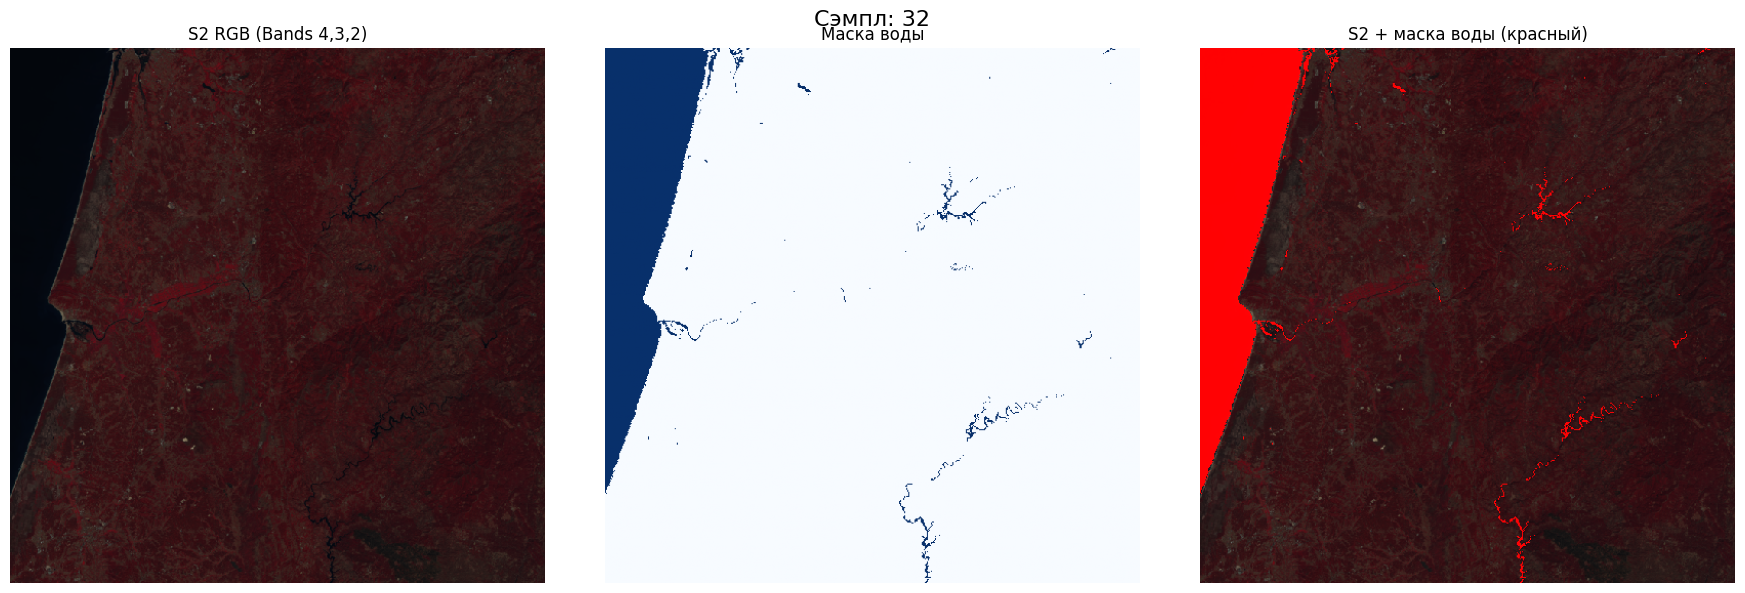


Статистика:
  - Размер маски: (522, 522)
  - Водная поверхность: 25,289 пикселей
  - Доля воды: 9.3%
СОЗДАНИЕ DATASET
Найдено 10 сэмплов (ограничено до 10)
Используем все 10 сэмплов
DataLoader готов: 10 батчей

Размер батча: S2=torch.Size([1, 3, 256, 256]), Маска=torch.Size([1, 256, 256])
Данные загружены успешно!
ИНФОРМАЦИЯ О ЗАГРУЖЕННЫХ ДАННЫХ
Загружено частей: 1
Список частей: [3]
  - Часть 3: 12 сэмплов

Всего сэмплов: 12
Используется для обучения: 10 сэмплов


In [9]:
# 10. ТЕСТИРОВАНИЕ
print("ТЕСТИРОВАНИЕ")
print("="*50)

# Определяем, какую часть использовать для тестирования
if successful_parts:
    # Используем первую успешно загруженную часть
    test_part = successful_parts[0]
    part_dir = os.path.join(EXTRACT_DIR, f"part{test_part}")

    print(f"Используем часть {test_part} для тестирования")

    # Находим сэмплы в этой части
    if os.path.exists(part_dir):
        sample_dirs = sorted([d for d in os.listdir(part_dir) if os.path.isdir(os.path.join(part_dir, d))])

        if sample_dirs:
            # Берем первый сэмпл для визуализации
            test_sample_name = sample_dirs[0]
            test_sample_path = os.path.join(part_dir, test_sample_name)

            print(f"Тестовый сэмпл: {test_sample_name}")
            print(f"Путь: {test_sample_path}")

            # Проверяем, существует ли путь
            if os.path.exists(test_sample_path):
                print("\n" + "="*50)
                print("ВИЗУАЛИЗАЦИЯ СЭМПЛА")
                print("="*50)
                visualize_sample(test_sample_path)
            else:
                print(f"Сэмпл не найден: {test_sample_path}")
        else:
            print(f"В части {test_part} нет сэмплов")
    else:
        print(f"Часть {test_part} не найдена: {part_dir}")
else:
    print("Нет успешно загруженных частей для тестирования")
    print("Проверьте загрузку данных в предыдущем блоке")

# 11. СОЗДАНИЕ DATASET
print("СОЗДАНИЕ DATASET")
print("="*50)

# Ограничиваем количество сэмплов для экономии памяти
MAX_SAMPLES = 10  # Не больше 10 сэмплов

# Создаем датасет из всех загруженных данных
dataset = S1S2WaterDataset(EXTRACT_DIR)

if len(dataset) > 0:
    # Ограничиваем количество сэмплов
    if len(dataset) > MAX_SAMPLES:
        print(f"В датасете {len(dataset)} сэмплов. Ограничиваем до {MAX_SAMPLES} для экономии памяти")
        # Создаем подвыборку
        from torch.utils.data import Subset
        indices = list(range(MAX_SAMPLES))
        dataset = Subset(dataset, indices)
        print(f"Используем {len(dataset)} сэмплов")
    else:
        print(f"Используем все {len(dataset)} сэмплов")

    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    print(f"DataLoader готов: {len(dataloader)} батчей")

    # Проверяем загрузку первого батча
    try:
        sample_batch = next(iter(dataloader))
        print(f"\nРазмер батча: S2={sample_batch[0].shape}, Маска={sample_batch[1].shape}")
        print("Данные загружены успешно!")
    except StopIteration:
        print("DataLoader пуст")
else:
    print("Нет данных для создания датасета")
    print("Убедитесь, что данные были успешно загружены и распакованы")

# 12. ИНФОРМАЦИЯ О ЗАГРУЖЕННЫХ ДАННЫХ
print("ИНФОРМАЦИЯ О ЗАГРУЖЕННЫХ ДАННЫХ")
print("="*50)

if successful_parts:
    print(f"Загружено частей: {len(successful_parts)}")
    print(f"Список частей: {successful_parts}")

    # Подробная информация о каждой части
    total_samples = 0
    for part_num in successful_parts:
        part_dir = os.path.join(EXTRACT_DIR, f"part{part_num}")
        if os.path.exists(part_dir):
            sample_dirs = [d for d in os.listdir(part_dir) if os.path.isdir(os.path.join(part_dir, d))]
            sample_count = len(sample_dirs)
            total_samples += sample_count
            print(f"  - Часть {part_num}: {sample_count} сэмплов")

    print(f"\nВсего сэмплов: {total_samples}")
    print(f"Используется для обучения: {min(MAX_SAMPLES, total_samples)} сэмплов")
else:
    print("Нет загруженных частей")

ДООБУЧЕНИЕ МОДЕЛИ U-NET
ПОДГОТОВКА ДАННЫХ
Тренировочных: 8
Валидационных: 2

 устройство: cuda
Загрузка модели для дообучения: /content/unet_water_s1s2_20260622_021848 (1)_new.pth
Модель загружена. Продолжение с эпохи 30
Начало дообучения на cuda
Эпох: 20, LR: 1e-05, Начало с эпохи: 30
--------------------------------------------------
  Эпоха 31, Батч 0: Loss = 0.5117
Эпоха 31/50: Train Loss = 0.5626, Val Loss = 0.5037
  Эпоха 32, Батч 0: Loss = 0.5599
Эпоха 32/50: Train Loss = 0.5426, Val Loss = 0.5079
  Эпоха 33, Батч 0: Loss = 0.5583
Эпоха 33/50: Train Loss = 0.5350, Val Loss = 0.4980
  Эпоха 34, Батч 0: Loss = 0.5350
Эпоха 34/50: Train Loss = 0.5253, Val Loss = 0.4902
  Эпоха 35, Батч 0: Loss = 0.5247
Эпоха 35/50: Train Loss = 0.5093, Val Loss = 0.4825
  Эпоха 36, Батч 0: Loss = 0.5820
Эпоха 36/50: Train Loss = 0.5147, Val Loss = 0.4762
  Эпоха 37, Батч 0: Loss = 0.5012
Эпоха 37/50: Train Loss = 0.5000, Val Loss = 0.4645
  Эпоха 38, Батч 0: Loss = 0.4960
Эпоха 38/50: Train Loss = 

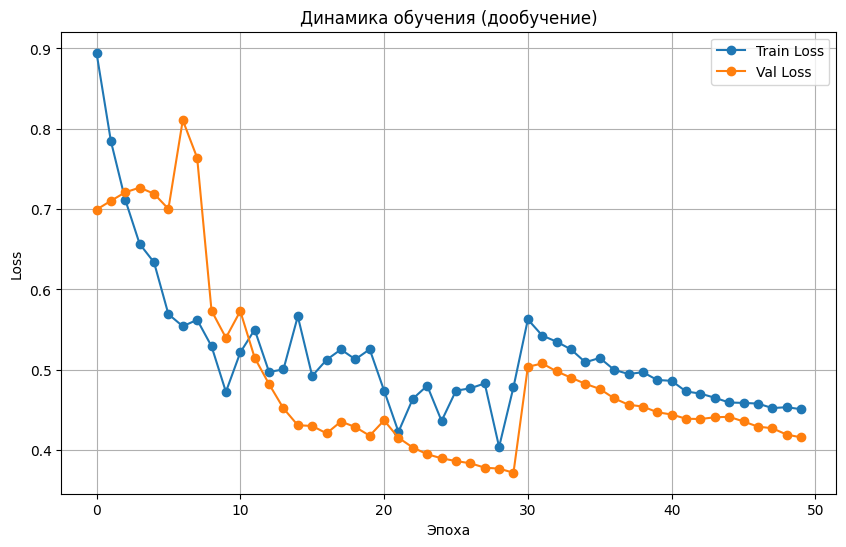

ТЕСТИРОВАНИЕ НА ПРИМЕРЕ


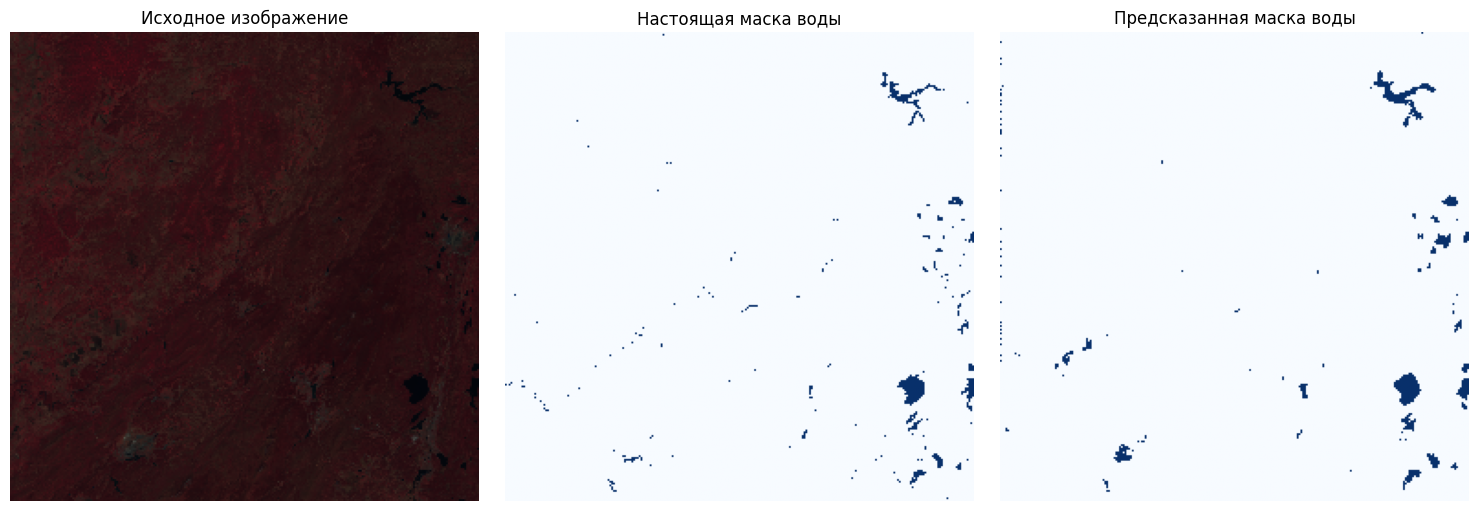

Метрики на тестовом примере:
  - Accuracy: 0.9913
  - IoU: 0.4827
  - Precision: 0.5694
  - Recall: 0.7601
  - F1-Score: 0.6511


In [18]:
# 13. ОБУЧЕНИЕ МОДЕЛИ СЕГМЕНТАЦИИ (U-Net)
if USE_PRETRAINED:
    print("ДООБУЧЕНИЕ МОДЕЛИ U-NET")
else:
    print("ОБУЧЕНИЕ МОДЕЛИ U-NET С НУЛЯ")
print("="*50)

import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import random_split
import time

# Простая реализация U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder (downsampling)
        for feature in features:
            self.encoder.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder (upsampling)
        for feature in reversed(features):
            self.decoder.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.decoder.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encoder
        for encoder in self.encoder:
            x = encoder(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.decoder), 2):
            x = self.decoder[idx](x)
            skip = skip_connections[idx // 2]

            # Обрезаем, если размеры не совпадают
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)

            x = torch.cat((skip, x), dim=1)
            x = self.decoder[idx + 1](x)

        return torch.sigmoid(self.final_conv(x))

# 14. ФУНКЦИЯ ОБУЧЕНИЯ
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4, device='cuda',
                start_epoch=0, train_losses=None, val_losses=None):
    """Обучение модели с поддержкой дообучения"""
    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    if train_losses is None:
        train_losses = []
    if val_losses is None:
        val_losses = []

    print(f"Начало {'до' if start_epoch > 0 else ''}обучения на {device}")
    print(f"Эпох: {epochs}, LR: {lr}, Начало с эпохи: {start_epoch}")
    print("-" * 50)

    for epoch in range(start_epoch, start_epoch + epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_idx, (images, masks) in enumerate(train_loader):
            images = images.to(device)
            masks = masks.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if batch_idx % 5 == 0:
                print(f"  Эпоха {epoch+1}, Батч {batch_idx}: Loss = {loss.item():.4f}")

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device).unsqueeze(1)

                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Эпоха {epoch+1}/{start_epoch+epochs}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    return train_losses, val_losses

# 15. ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ
print("ПОДГОТОВКА ДАННЫХ")
print("="*50)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Тренировочных: {train_size}")
print(f"Валидационных: {val_size}")

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

# 16. СОЗДАНИЕ ИЛИ ЗАГРУЗКА МОДЕЛИ
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\n устройство: {device}")

if USE_PRETRAINED and 'PRETRAINED_MODEL_PATH' in dir():
    print(f"Загрузка модели для дообучения: {PRETRAINED_MODEL_PATH}")
    checkpoint = torch.load(PRETRAINED_MODEL_PATH, map_location=device)

    model = UNet(in_channels=3, out_channels=1)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)

    # Восстанавливаем историю потерь
    start_epoch = checkpoint.get('epoch', 0)
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])

    print(f"Модель загружена. Продолжение с эпохи {start_epoch}")
else:
    print("Создание новой модели с нуля")
    model = UNet(in_channels=3, out_channels=1)
    start_epoch = 0
    train_losses = []
    val_losses = []

# 17. ЗАПУСК ОБУЧЕНИЯ
# Настраиваем параметры обучения
if USE_PRETRAINED:
    epochs = 20  # Меньше эпох для дообучения
    lr = 1e-5   # Меньшая скорость обучения
else:
    epochs = 15  # Полный цикл для нового обучения
    lr = 1e-4

train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    lr=lr,
    device=device,
    start_epoch=start_epoch,
    train_losses=train_losses,
    val_losses=val_losses
)

# 18. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*50)

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
title = 'Динамика обучения'
if USE_PRETRAINED:
    title += ' (дообучение)'
plt.title(title)
plt.legend()
plt.grid(True)
plt.show()

# 19. ТЕСТИРОВАНИЕ НА ОДНОМ ИЗОБРАЖЕНИИ
print("ТЕСТИРОВАНИЕ НА ПРИМЕРЕ")
print("="*50)

def predict_and_visualize(model, dataset, idx, device='cuda'):
    """Предсказание и визуализация с расчетом IoU"""
    model.eval()

    image, mask = dataset[idx]
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(image)
        pred = pred.squeeze(0).squeeze(0).cpu().numpy()

    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image.squeeze(0).cpu().numpy().transpose(1, 2, 0))
    axes[0].set_title('Исходное изображение')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='Blues')
    axes[1].set_title('Настоящая маска воды')
    axes[1].axis('off')

    axes[2].imshow(pred > 0.5, cmap='Blues')
    axes[2].set_title('Предсказанная маска воды')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Расчет метрик
    pred_binary = (pred > 0.5).astype(np.float32)
    mask_np = mask.numpy()

    # Accuracy
    accuracy = np.mean((pred_binary == mask_np).astype(np.float32))

    # IoU
    intersection = np.sum(pred_binary * mask_np)
    union = np.sum(pred_binary) + np.sum(mask_np) - intersection
    iou = intersection / union if union > 0 else 0

    # Дополнительные метрики
    tp = np.sum(pred_binary * mask_np)  # True Positive
    fp = np.sum(pred_binary * (1 - mask_np))  # False Positive
    fn = np.sum((1 - pred_binary) * mask_np)  # False Negative

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Метрики на тестовом примере:")
    print(f"  - Accuracy: {accuracy:.4f}")
    print(f"  - IoU: {iou:.4f}")
    print(f"  - Precision: {precision:.4f}")
    print(f"  - Recall: {recall:.4f}")
    print(f"  - F1-Score: {f1:.4f}")

    return accuracy, iou, precision, recall, f1

if val_size > 0:
    test_idx = train_size
    predict_and_visualize(model, dataset, test_idx, device)
else:
    print("Нет валидационных данных для тестирования")

Сохраните текущую модель (уже есть в коде)

Скачайте больше частей датасета (part2.zip, part3.zip)

Добавьте аугментации в DataLoader

Запустите дообучение с меньшей скоростью (1e-5)

Логи
- Эпоха: 10 (обучение на 5-й части)
  - Train Loss: 0.4725107749303182
  - Val Loss: 0.5398116111755371

- Эпоха: 20 (обучение на 1-й части)
  - Train Loss: 0.5255
  - Val Loss: 0.4180

- Эпоха: 30 (повторный прогон на 1-й части)
  - Train Loss: 0.4784
  - Val Loss: 0.3719

- Эпоха: 50 (обучение на 3-й части)
  - Train Loss: 0.4588
  - Val Loss: 0.3934

In [16]:
# 20. СОХРАНЕНИЕ МОДЕЛИ
print("СОХРАНЕНИЕ МОДЕЛИ")
print("="*50)

import os
import torch
import json
from datetime import datetime
from google.colab import files

def save_and_download_model(model, optimizer, epoch, train_losses, val_losses, model_name="unet_water"):
    """
    Сохраняет модель и автоматически скачивает на компьютер
    """
    temp_dir = "/tmp/models"
    os.makedirs(temp_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_filename = f"{model_name}_{timestamp}.pth"
    model_path = os.path.join(temp_dir, model_filename)

    # Сохраняем состояние модели
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict() if optimizer else None,
        'epoch': epoch,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'model_name': model_name,
        'timestamp': timestamp,
        'num_samples': len(dataset) if hasattr(dataset, '__len__') else 0
    }

    torch.save(checkpoint, model_path)
    print(f"Модель сохранена: {model_path}")

    # Сохраняем метаданные
    metadata = {
        'model_name': model_name,
        'filename': model_filename,
        'timestamp': timestamp,
        'epoch': epoch,
        'train_loss': train_losses[-1] if train_losses else None,
        'val_loss': val_losses[-1] if val_losses else None,
        'num_samples': len(dataset) if hasattr(dataset, '__len__') else 0
    }

    metadata_filename = f"{model_name}_{timestamp}_metadata.json"
    metadata_path = os.path.join(temp_dir, metadata_filename)
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"Метаданные сохранены: {metadata_path}")

    # Автоматическое скачивание
    print("СКАЧИВАНИЕ НА КОМПЬЮТЕР")
    print("="*50)

    print(f"Скачивание модели: {model_filename}")
    files.download(model_path)

    print(f"Скачивание метаданных: {metadata_filename}")
    files.download(metadata_path)

    print("\nФайлы скачаны в папку 'Загрузки' вашего компьютера!")

    return model_path, metadata

# ВОССТАНАВЛИВАЕМ ОПТИМИЗАТОР
# Создаем оптимизатор заново (если он не определен)
try:
    # Проверяем, существует ли optimizer
    optimizer
except NameError:
    print("Создаем новый оптимизатор для сохранения...")
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Проверяем, что все необходимые переменные существуют
print("\nПроверка переменных перед сохранением:")
print(f"  - model: {'✅' if 'model' in dir() else '❌'}")
print(f"  - optimizer: {'✅' if 'optimizer' in dir() else '❌'}")
print(f"  - train_losses: {'✅' if 'train_losses' in dir() else '❌'}")
print(f"  - val_losses: {'✅' if 'val_losses' in dir() else '❌'}")

# Сохраняем модель
if 'model' in dir() and 'train_losses' in dir() and 'val_losses' in dir():
    # Используем количество эпох из train_losses
    epochs_completed = len(train_losses)

    print(f"\nСохранение модели после {epochs_completed} эпох обучения")

    model_path, metadata = save_and_download_model(
        model=model,
        optimizer=optimizer,
        epoch=epochs_completed,
        train_losses=train_losses,
        val_losses=val_losses,
        model_name="unet_water_s1s2"
    )

    print(f"\nМетаданные модели:")
    print(f"  - Имя: {metadata['model_name']}")
    print(f"  - Эпоха: {metadata['epoch']}")
    print(f"  - Train Loss: {metadata['train_loss']:.4f}")
    print(f"  - Val Loss: {metadata['val_loss']:.4f}")
    print(f"  - Кол-во сэмплов: {metadata['num_samples']}")

    print("МОДЕЛЬ УСПЕШНО СОХРАНЕНА И СКАЧАНА!")
    print("="*50)
else:
    print("\nОшибка: Не все переменные определены для сохранения")
    print("Убедитесь, что модель была обучена и переменные существуют")

СОХРАНЕНИЕ МОДЕЛИ

Проверка переменных перед сохранением:
  - model: ✅
  - optimizer: ✅
  - train_losses: ✅
  - val_losses: ✅

Сохранение модели после 50 эпох обучения
Модель сохранена: /tmp/models/unet_water_s1s2_20260623_001002.pth
Метаданные сохранены: /tmp/models/unet_water_s1s2_20260623_001002_metadata.json
СКАЧИВАНИЕ НА КОМПЬЮТЕР
Скачивание модели: unet_water_s1s2_20260623_001002.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Скачивание метаданных: unet_water_s1s2_20260623_001002_metadata.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Файлы скачаны в папку 'Загрузки' вашего компьютера!

Метаданные модели:
  - Имя: unet_water_s1s2
  - Эпоха: 50
  - Train Loss: 0.4588
  - Val Loss: 0.3934
  - Кол-во сэмплов: 10
МОДЕЛЬ УСПЕШНО СОХРАНЕНА И СКАЧАНА!


Загружаем модель. Потом получаем фото карты, вывод рек

ЗАГРУЗКА МОДЕЛИ И ВЫДЕЛЕНИЕ ВОДЫ
ВЫБОР МОДЕЛИ

Найдены модели в /content/:
  1. unet_water_s1s2_20260622_021848 (1)_new.pth (118.5 МБ)
  2. unet_water_s1s2_20260622_021848.pth (118.5 МБ)

Выберите действие:
1. Использовать модель из /content/
2. Загрузить новую модель с компьютера
Введите номер действия (1 или 2): 2

ЗАГРУЗКА МОДЕЛИ С КОМПЬЮТЕРА
Нажмите 'Choose Files' и выберите файл модели (.pth)


Saving unet_water_s1s2_20260623_001002.pth to unet_water_s1s2_20260623_001002.pth

Загружен файл: unet_water_s1s2_20260623_001002.pth

ЗАГРУЗКА ИЗОБРАЖЕНИЯ ДЛЯ АНАЛИЗА
Нажмите 'Choose Files' и выберите спутниковый снимок


Saving Скриншот 19-06-2026 130701.jpg to Скриншот 19-06-2026 130701 (1).jpg

Загружено изображение: Скриншот 19-06-2026 130701 (1).jpg
Используемое устройство: cuda
ЗАПУСК ОБРАБОТКИ ИЗОБРАЖЕНИЯ
Загрузка модели: unet_water_s1s2_20260623_001002.pth
Модель загружена успешно!
  - Эпоха: 50
  - Train Loss: 0.45884621888399124
  - Val Loss: 0.3934040069580078
Загрузка изображения: Скриншот 19-06-2026 130701 (1).jpg
Размер изображения: (3, 256, 256)
Выполнение предсказания...
Предсказание завершено!
  - Водная поверхность: 3,081 пикселей
  - Доля воды: 4.7%


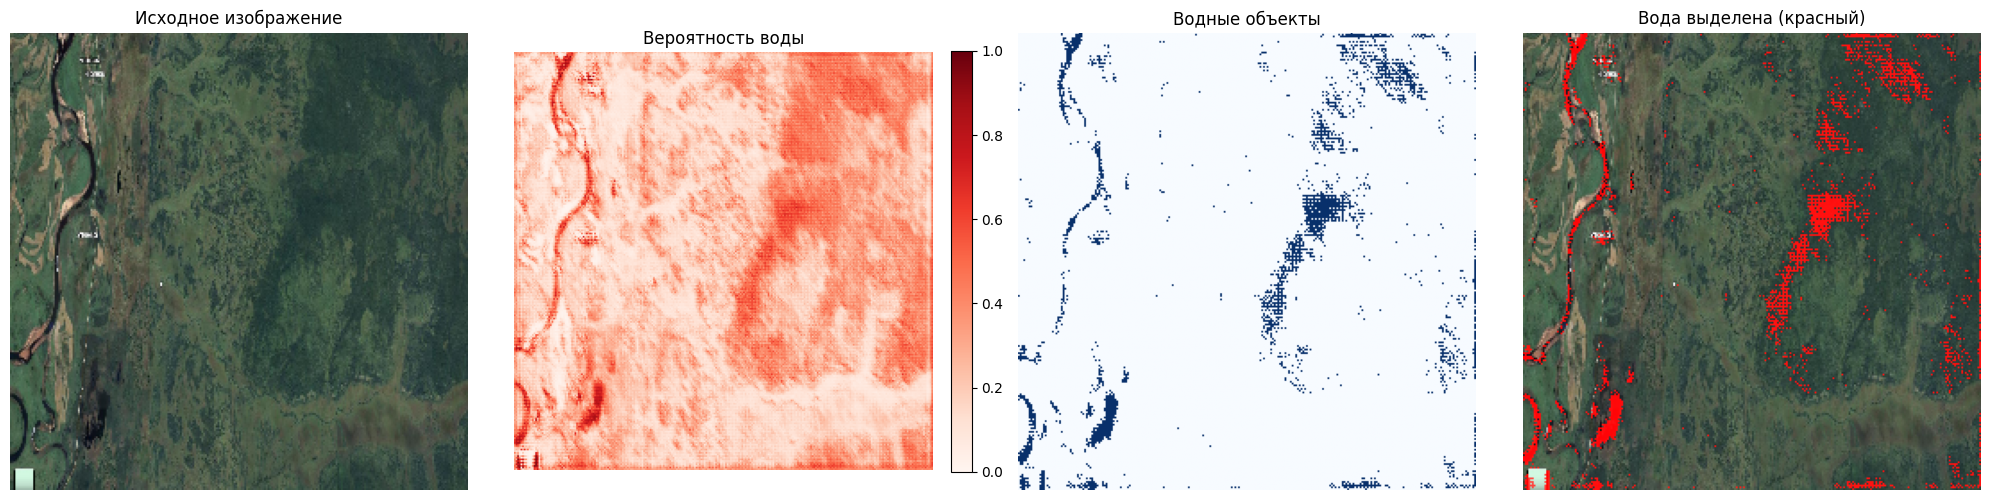

In [17]:
# Боевой тест с скриншотом google карт
print("ЗАГРУЗКА МОДЕЛИ И ВЫДЕЛЕНИЕ ВОДЫ")
print("="*50)

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import rasterio
from rasterio.plot import show
import os
from google.colab import files
import cv2
import glob
import json

# 1. ЗАГРУЗКА МОДЕЛИ
def load_trained_model(model_path, device='cuda'):
    """
    Загружает сохраненную модель
    """
    print(f"Загрузка модели: {model_path}")

    if not os.path.exists(model_path):
        print(f"Файл не найден: {model_path}")
        return None

    try:
        checkpoint = torch.load(model_path, map_location=device)

        # Создаем модель той же архитектуры
        model = UNet(in_channels=3, out_channels=1)
        model.load_state_dict(checkpoint['model_state_dict'])
        model = model.to(device)
        model.eval()

        print(f"Модель загружена успешно!")
        print(f"  - Эпоха: {checkpoint.get('epoch', '?')}")
        print(f"  - Train Loss: {checkpoint.get('train_losses', ['?'])[-1] if checkpoint.get('train_losses') else '?'}")
        print(f"  - Val Loss: {checkpoint.get('val_losses', ['?'])[-1] if checkpoint.get('val_losses') else '?'}")

        return model
    except Exception as e:
        print(f"Ошибка при загрузке модели: {e}")
        return None

# 2. ЗАГРУЗКА И ОБРАБОТКА ИЗОБРАЖЕНИЯ
def load_and_preprocess_image(image_path, target_size=(256, 256)):
    """
    Загружает изображение и подготавливает для модели
    """
    print(f"Загрузка изображения: {image_path}")

    try:
        # Пробуем загрузить как GeoTIFF
        if image_path.endswith('.tif') or image_path.endswith('.tiff'):
            with rasterio.open(image_path) as src:
                # Берем RGB каналы
                if src.count >= 3:
                    img = src.read([1, 2, 3])
                else:
                    img = src.read(1)
                    img = np.stack([img]*3, axis=0)

                # Нормализация
                img = img.astype(np.float32)
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)
                img = np.clip(img, 0, 1)
        else:
            # Загружаем как обычное изображение
            img = Image.open(image_path)
            img = np.array(img)

            # Если изображение в оттенках серого
            if len(img.shape) == 2:
                img = np.stack([img]*3, axis=2)
            # Если RGBA -> RGB
            elif img.shape[2] == 4:
                img = img[:, :, :3]

            # Транспонируем в формат (C, H, W)
            img = np.transpose(img, (2, 0, 1))

            # Нормализация
            img = img.astype(np.float32) / 255.0

        # Ресайзим
        if img.shape[1] != target_size[0] or img.shape[2] != target_size[1]:
            img_tensor = torch.tensor(img).unsqueeze(0)
            img_tensor = torch.nn.functional.interpolate(
                img_tensor,
                size=target_size,
                mode='bilinear',
                align_corners=False
            ).squeeze(0).numpy()
            img = img_tensor

        return img

    except Exception as e:
        print(f"Ошибка при загрузке изображения: {e}")
        return None

# 3. ПРЕДСКАЗАНИЕ И ВИЗУАЛИЗАЦИЯ
def predict_water(model, image, device='cuda', threshold=0.5):
    """
    Предсказывает водные объекты на изображении
    """
    model.eval()

    # Преобразуем в тензор
    image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).to(device)

    # Предсказание
    with torch.no_grad():
        pred = model(image_tensor)
        pred = pred.squeeze(0).squeeze(0).cpu().numpy()

    # Бинаризация
    pred_binary = (pred > threshold).astype(np.float32)

    return pred, pred_binary

def visualize_prediction(image, pred, pred_binary, save_path=None):
    """
    Визуализирует оригинальное изображение и предсказания
    """
    # Подготовка изображения для отображения
    if image.shape[0] == 3:
        img_display = np.transpose(image, (1, 2, 0))
    else:
        img_display = image

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Оригинал
    axes[0].imshow(img_display)
    axes[0].set_title('Исходное изображение')
    axes[0].axis('off')

    # Предсказание (вероятности)
    im1 = axes[1].imshow(pred, cmap='Reds', vmin=0, vmax=1)
    axes[1].set_title('Вероятность воды')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Бинарная маска воды
    axes[2].imshow(pred_binary, cmap='Blues')
    axes[2].set_title('Водные объекты')
    axes[2].axis('off')

    # Наложение маски на изображение
    overlay = img_display.copy()
    # Делаем воду красной/синей
    overlay[pred_binary > 0, 0] = 1  # R
    overlay[pred_binary > 0, 1] = overlay[pred_binary > 0, 1] * 0.3  # G
    overlay[pred_binary > 0, 2] = overlay[pred_binary > 0, 2] * 0.3  # B
    axes[3].imshow(overlay)
    axes[3].set_title('Вода выделена (красный)')
    axes[3].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Результат сохранен: {save_path}")

    plt.show()

# 4. ОСНОВНОЙ ПРОЦЕСС
def process_image_with_model(model_path, image_path, device='cuda', threshold=0.5):
    """
    Полный процесс: загрузка модели -> обработка изображения -> предсказание
    """
    print("ЗАПУСК ОБРАБОТКИ ИЗОБРАЖЕНИЯ")
    print("="*60)

    # Загружаем модель
    model = load_trained_model(model_path, device)
    if model is None:
        return None, None

    # Загружаем изображение
    image = load_and_preprocess_image(image_path)
    if image is None:
        return None, None

    print(f"Размер изображения: {image.shape}")

    # Предсказываем
    print("Выполнение предсказания...")
    pred, pred_binary = predict_water(model, image, device, threshold)

    print(f"Предсказание завершено!")
    print(f"  - Водная поверхность: {np.sum(pred_binary > 0):,} пикселей")
    print(f"  - Доля воды: {np.sum(pred_binary > 0) / pred_binary.size * 100:.1f}%")

    # Визуализация
    visualize_prediction(image, pred, pred_binary)

    return pred, pred_binary

# 5. ВЫБОР МОДЕЛИ
print("ВЫБОР МОДЕЛИ")
print("="*50)

# Проверяем модели в /content/
content_models = glob.glob("/content/*.pth")

if content_models:
    print("\nНайдены модели в /content/:")
    for i, model_file in enumerate(content_models):
        model_name = os.path.basename(model_file)
        size_mb = os.path.getsize(model_file) / (1024 * 1024)
        print(f"  {i+1}. {model_name} ({size_mb:.1f} МБ)")

    print("\nВыберите действие:")
    print("1. Использовать модель из /content/")
    print("2. Загрузить новую модель с компьютера")

    choice = input("Введите номер действия (1 или 2): ").strip()

    if choice == "1":
        try:
            model_idx = int(input(f"Введите номер модели (1-{len(content_models)}): ").strip()) - 1
            if 0 <= model_idx < len(content_models):
                model_path = content_models[model_idx]
                print(f"\nВыбрана модель: {os.path.basename(model_path)}")
            else:
                print("Неверный номер. Загрузка с компьютера...")
                choice = "2"
        except:
            print("Неверный ввод. Загрузка с компьютера...")
            choice = "2"

if not content_models or choice == "2":
    print("\nЗАГРУЗКА МОДЕЛИ С КОМПЬЮТЕРА")
    print("="*50)
    print("Нажмите 'Choose Files' и выберите файл модели (.pth)")

    uploaded = files.upload()

    if uploaded:
        model_path = list(uploaded.keys())[0]
        print(f"\nЗагружен файл: {model_path}")
    else:
        print("Модель не загружена")
        exit()

# 6. ЗАГРУЗКА ИЗОБРАЖЕНИЯ С КОМПЬЮТЕРА
print("\nЗАГРУЗКА ИЗОБРАЖЕНИЯ ДЛЯ АНАЛИЗА")
print("="*50)
print("Нажмите 'Choose Files' и выберите спутниковый снимок")

uploaded_image = files.upload()

if uploaded_image:
    image_path = list(uploaded_image.keys())[0]
    print(f"\nЗагружено изображение: {image_path}")

    # Проверяем устройство
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Используемое устройство: {device}")

    # Обрабатываем изображение
    pred, pred_binary = process_image_with_model(
        model_path=model_path,
        image_path=image_path,
        device=device,
        threshold=0.5
    )
else:
    print("Изображение не загружено")

Логи картинок
На 20 эпохе
  - Водная поверхность: 1,900 пикселей
  - Доля воды: 2.9%

На 30 эпохе
